# Generación de Texto con modelos GPT

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion5/1-text-generation.ipynb)

En este notebook harémos uso de un modelo tipo GPT-2 pre-entrenado en idioma español que utilizaremos para generar texto a partir de un contexto inicial que proveerémos. Luego, harémos fine tuning a este modelo con un dataset de chistes en español y observar como cambia la generación de texto en función del dataset que utilicemos.

#### Referencias
- Dataset: https://huggingface.co/datasets/mrm8488/CHISTES_spanish_jokes
- [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [GPT2 Spanish](https://huggingface.co/DeepESP/gpt2-spanish)
- [Fine-Tune a non-Englush GPT-2 Model with Huggingface](https://www.philschmid.de/fine-tune-a-non-english-gpt-2-model-with-huggingface)

In [1]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

C:\Users\rchic\AppData\Local\Temp\ipykernel_40624\2396000874.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Generative pre-training Transformer - GPT

![](https://github.com/Ohtar10/icesi-nlp/blob/main/assets/gpt.png?raw=1)

Los modelos tipo GPT, introducidos por Radfor, et.al., de OpenAI, al igual que los modelos BERT, hacen uso extensivo de la arquitectura de transformers como hemos estado viendo. Las diferencias claves se podrían resumir en:

1. GPT utiliza bloques de **Transformer Decoder** encadenados, mientras que el modelo BERT utiliza bloques de *Transformer Encoder*
2. GPT se centra en la generación de texto basado en un contexto, la tarea principal es la predicción del siguiente token en la secuencia, mientras que BERT se centra en el completado de partes de una secuencia, en función de un contexto anterior y posterior a la secuencia de entrada. Entonces BERT se centra en la construicción de representación de lenguage, mientras que GPT se centra en la generación de texto en función de un contexto.

Sin embargo, ambos se basan en la misma premisa de pre-entrenar el modelo en tareas no-supervisadas o semi-supervisadas para que el modelo aprenda las representaciones semánticas del lenguage y luego al modelo se le pueda hacer fine tuning a tareas posteriores.

In [6]:
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer


device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "mrm8488/spanish-gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id

model.resize_token_embeddings(len(tokenizer))

model

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50266, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [3]:
modules = [m for m, _ in model.named_modules()]
modules

['',
 'transformer',
 'transformer.wte',
 'transformer.wpe',
 'transformer.drop',
 'transformer.h',
 'transformer.h.0',
 'transformer.h.0.ln_1',
 'transformer.h.0.attn',
 'transformer.h.0.attn.c_attn',
 'transformer.h.0.attn.c_proj',
 'transformer.h.0.attn.attn_dropout',
 'transformer.h.0.attn.resid_dropout',
 'transformer.h.0.ln_2',
 'transformer.h.0.mlp',
 'transformer.h.0.mlp.c_fc',
 'transformer.h.0.mlp.c_proj',
 'transformer.h.0.mlp.act',
 'transformer.h.0.mlp.dropout',
 'transformer.h.1',
 'transformer.h.1.ln_1',
 'transformer.h.1.attn',
 'transformer.h.1.attn.c_attn',
 'transformer.h.1.attn.c_proj',
 'transformer.h.1.attn.attn_dropout',
 'transformer.h.1.attn.resid_dropout',
 'transformer.h.1.ln_2',
 'transformer.h.1.mlp',
 'transformer.h.1.mlp.c_fc',
 'transformer.h.1.mlp.c_proj',
 'transformer.h.1.mlp.act',
 'transformer.h.1.mlp.dropout',
 'transformer.h.2',
 'transformer.h.2.ln_1',
 'transformer.h.2.attn',
 'transformer.h.2.attn.c_attn',
 'transformer.h.2.attn.c_proj',
 'tran

Observermos un ejemplo de generación simple.

In [4]:
text = "Había una vez"
best = 10

with torch.no_grad():
    tokens = tokenizer(text, return_tensors='pt')['input_ids'].to(device)
    print("Dimensiones de la entrada:", tokens.shape)
    output = model(input_ids=tokens)
    print("Dimensiones de la salida:", output.logits.shape)
    output = output.logits[0, -1, :]
    print("Dimensiones del último token de la secuencia:", output.shape)
    probs = torch.softmax(output, dim=-1)
    print("Dimensiones de la probabilidad de los tokens:", probs.shape)
    sorted_probs = torch.argsort(probs, dim=-1, descending=True)
    print({tokenizer.decode(token): f"{prob.cpu().numpy() * 100:.2f}%" for token, prob in zip(sorted_probs[:best], probs[sorted_probs[:best]])})

Dimensiones de la entrada: torch.Size([1, 3])
Dimensiones de la salida: torch.Size([1, 3, 50266])
Dimensiones del último token de la secuencia: torch.Size([50266])
Dimensiones de la probabilidad de los tokens: torch.Size([50266])
{' un': '30.17%', ' una': '25.06%', ',': '14.50%', ' en': '8.18%', ' que': '5.96%', '...': '5.87%', ' dos': '1.74%', '.': '0.72%', ' tres': '0.67%', ' uno': '0.34%'}


## Implementando una función de generación

Ahora, la idea es que este modelo nos sirva para generar texto de forma recurrente e incremental. En la última capa de los modelos tipo GPT encontrarémos un tensor con forma $(b, s, v)$, donde:

- $b$: Es el tamaño del bache, o la cantidad de secuencias a procesar.
- $s$: Es la longitud de la secuencia de entrada.
- $v$: Es el tamaño del vocabulario del modelo, cuantos tokens soporta.

Pero este es el tensor de salida, por qué tiene la forma de la secuencia de entrada?, porque cada posición en la salida corresponde a la la predicción del siguiente token de esa posición en la secuencia de entrada. En otras palabras, lo que obtenemos como predicción, es una secuencia de igual tamaño a la de entrada, movida un token hacia adelante, lo que efectivamente nos predice un solo token a la vez y por ende, el token que nos insteresa, es el último.

Lo que obtenemos en este tensor es además los logits de TODO el vocabulario del modelo, con los cuales podemos calcular las probabilidades de que cada uno sea el que continue en la secuencia. Hay varias formas de decodificar el siguiente token, la más fácil de implementar sería una decodificación codiciosa (greedy) del siguiente token, que consiste simplemente en seleccionar el token con la probabilidad más alta. Este es un enfoque simple y efectivo para algunos casos, pero al mismo tiempo sufre de poca variabilidad e incluso puede caer en generación repetitiva.

Otra opción es el muestreo, ya que justamente podemos obtener probabilidades del siguiente token, lo más lógico sería muestrear con esas opciones de probabilidad, de este modo podemos obtener mayor diversidad a la hora de generar el texto, al costo eso si de que haya mayor aleatoridad ya que se le daría la oportunidad a incluso tokens con baja probabilidad, de ser seleccionados.

Otra opción podría ser un balanceo entre una decodificación greedy y una por muestreo, en función de otro hiperparámetro que podemos definir. Esta sería una técnica muy común en el contexto de Reinforcement Learning llamade e-greedy. Se hace la aclaración de que en este ejemplo no harémos nada de RL, solamente se hace mención de esta técnica para balancear entre explotación y exploración.

In [5]:
import torch.nn as nn
import numpy as np
import pandas as pd
from typing import Optional, Tuple
from transformers.tokenization_utils_base import PreTrainedTokenizerBase


def generate(
        model: nn.Module,
        tokenizer: PreTrainedTokenizerBase,
        start: str,
        max_length: int = 100,
        eps: float = 0.5,
        top_n: int = 5,
        return_iterations: bool = False,
        device: str = "cpu") -> Tuple[str, Optional[pd.DataFrame]]:

    output = [start]
    iterations = []
    with torch.no_grad():
        input_ids = tokenizer(output[-1], return_tensors='pt')['input_ids'].to(device)
        for _ in range(max_length):
            # Tomamos los logits producidos por la última capa del modelo
            # Estos corresponden al siguiente token por cada posición de la cadena
            logits = model(input_ids=input_ids).logits
            # Por lo tanto, el que nos interesa es el último, que correspondería a la
            # predicción del siguiente token después del final de la cadena original
            # A este aplicamos un softmax para obtener las probabilidades por cada
            # token del vocabulario para estar presente en la cadena.
            probs = torch.softmax(logits[0, -1, :], dim=-1)
            # Simplemente ordenamos por probabilidad de forma descendente
            sorted_tokens = torch.argsort(probs, dim=-1, descending=True)

            # Utilizamos una politica tipo e-greedy para obtener el siguiente token de la secuencia
            # Un eps>=1 quiere decir que siempre se va seleccionar el token de forma 'greedy', es decir
            # siempre se toma el token con probabilidad más alta.

            # Un eps=0 quiere decir que siempre se va a muestrear el siguiente token en función
            # de las probabilidades de cada token

            # Un 0<eps<1 va a balancear de forma binomial entre tomar el token con la
            # probabilidad más alta y muestrear el token en función de sus probabilidades.
            if np.random.random_sample(1)[0] < eps:
                # Se toma el mejor token
                next_token = sorted_tokens[0].unsqueeze(dim=0)
            else:
                # Se muetrea el token de la probabilidad de distribución
                next_token = torch.multinomial(probs, 1)

            if return_iterations:
                # Mantenemos pista de todas las iteraciones para análisis
                iteration = {'input': ''.join(output)}
                best_n = sorted_tokens[:top_n].cpu().tolist()
                choices = {f'Choice #{choice+1}': f'{tokenizer.decode(token)} ({prob:.4f})' for choice, (token, prob) in enumerate(zip(best_n, probs[best_n].cpu().tolist()))}
                iteration.update(choices)
                iterations.append(iteration)

            output.append(tokenizer.decode(next_token))
            input_ids = torch.cat([input_ids, next_token.unsqueeze(dim=0)], dim=-1)

        output_text = ''.join(output)
        if not return_iterations:
            return output_text, None
        else:
            df = pd.DataFrame(iterations)
            return output_text, df

Ahora observemos que pasa cuando generamos texto con nuestra función y algunos parámetros.

Primero, observemos que pasa cuando pasamos un `eps=1` que quiere decir que la generación va a ser de tipo greedy:

In [6]:
output_text, iterations_df = generate(model, tokenizer, text, max_length=15, eps=1.0, top_n=10, return_iterations=True, device=device)
print(output_text)
iterations_df.head(15)

Había una vez un hombre que se llamaba a sí mismo "El hombre de la bolsa".


,input,Choice #1,Choice #2,Choice #3,Choice #4,Choice #5,Choice #6,Choice #7,Choice #8,Choice #9,Choice #10
0,Había una vez,un (0.3017),una (0.2506),", (0.1450)",en (0.0818),que (0.0596),... (0.0587),dos (0.0174),. (0.0072),tres (0.0067),uno (0.0034)
1,Había una vez un,hombre (0.1397),rey (0.0564),niño (0.0535),joven (0.0460),chico (0.0347),pequeño (0.0321),príncipe (0.0192),tipo (0.0166),muchacho (0.0164),viejo (0.0148)
2,Había una vez un hombre,que (0.3329),llamado (0.1111),", (0.0773)",y (0.0529),... (0.0431),de (0.0326),en (0.0320),con (0.0285),muy (0.0203),. (0.0126)
3,Había una vez un hombre que,se (0.1276),tenía (0.0634),vivía (0.0624),no (0.0623),era (0.0422),estaba (0.0276),amaba (0.0263),", (0.0255)",fue (0.0238),había (0.0182)
4,Había una vez un hombre que se,llamaba (0.1948),había (0.0505),enamoró (0.0370),sentó (0.0296),convirtió (0.0198),casó (0.0181),sentía (0.0149),hizo (0.0149),fue (0.0146),encontró (0.0121)
5,Había una vez un hombre que se llamaba,a (0.0438),... (0.0425),John (0.0128),""" (0.0104)",José (0.0101),David (0.0097),Peter (0.0088),Juan (0.0086),Henry (0.0081),A (0.0074)
6,Había una vez un hombre que se llamaba a,sí (0.8622),si (0.1250),él (0.0034),uno (0.0008),Sí (0.0007),un (0.0006),su (0.0005),mismo (0.0005),la (0.0004),engaño (0.0004)
7,Había una vez un hombre que se llamaba a sí,mismo (0.9944),propio (0.0017),misma (0.0015),m (0.0003),mismo (0.0002),a (0.0002),solo (0.0002),", (0.0002)",sí (0.0001),y (0.0001)
8,Había una vez un hombre que se llamaba a sí mismo,""" (0.1287)",el (0.0575),... (0.0179),un (0.0161),señor (0.0145),Señor (0.0144),Dios (0.0132),rey (0.0110),", (0.0099)",Capitán (0.0095)
9,Había una vez un hombre que se llamaba a sí mi...,El (0.0862),el (0.0581),Padre (0.0191),Dios (0.0169),Señor (0.0150),La (0.0131),señor (0.0124),Rey (0.0114),S (0.0096),Sr (0.0083)


Observamos como el input progresa a la vez que las opciones de tokens que hay. Sin importar cuantas veces invoquemos a la función con los mismos parámetros, siempre vamos a obtener los mismos resultados.

Ahora, observemos que pasa si introducimos exploración al reducir el `eps=0.5`, lo cual nos dice que aproximadamente la mitad de las veces va a elegir el siguiente token muestreando y la otra mitad explotando.

In [7]:
output_text, _ = generate(model, tokenizer, text, max_length=100, eps=0.5, device=device)
print(output_text)

Había una vez un chico llamado Jack el matón que se burlaba sin parar de los chicos del dream burning.Justo y sin parar, Jack quedó atrapado en un mundo de locura.La mayoría de las veces, Jack estaba en la cárcel.Pero no era un chico del dream burning.Si no te gusta el dream burning, no te puedes quedar.¿Vas a estar bien?Voy a estar bien.Sean, ¿qué pasó?¿Qué pasó,


En este caso, cada vez que invoquemos a la función, vamos a obtener una respuesta diferente, a veces más coherente y otras veces menos. Vale la pena realizar varias pruebas para observar los resultados hasta encontrar un balance.

### Generando texto con las utilidades del modelo

Ahora, la clase de Huggingface implementa la función `generate` que hace la labor de generación por nosotros, incluyendo las opciones de muestreo y explotación como hemos observado. Solo que además permite otra serie de parámetros y opciones para controlar la generación de texto. Para más información se recomienda estudiar:

- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246), Capitulo 5
- https://huggingface.co/docs/transformers/v4.41.3/en/main_classes/text_generation#transformers.GenerationConfig
- https://huggingface.co/docs/transformers/v4.41.3/en/main_classes/text_generation#transformers.GenerationMixin.generate

In [8]:
output = model.generate(tokens, pad_token_id=tokenizer.eos_token_id, max_length=100, do_sample=True, temperature=0.5, top_k=0)
print(tokenizer.decode(output[0]))

Había una vez, una vez...¡Dios mío!¿Estás bien?Sí.Gracias.¿Qué pasa con la cámara?¿Qué?¿Qué pasa?¿Qué?¿Qué pasa?¿Qué?¿Qué?¿Qué?¡Dios mío!¿Qué?¿Qué?¡Dios mío!¿Qué?¿Qué?¡Dios mío!¡Dios mío!¿Qué?¿Qué?¿Qué?¡Dios mío!¿Qué?¡Dios mío!¿Qué?


## Fine tuning

Ahora, intentemos hacer fine tuning a nuestro modelo. Intentemos entrenarlo en un corpus de chistes en idioma español y ver como la narrativa de su output cambia.

##### Nota
Lastimosamente, este dataset es muy pequeño y la distribución del texto es muy diferente a la distribución de texto con la cual fue entrenado el modelo original, por lo que no se esperan resultados significativamente ejemplares. Sin embargo, el objetivo es observar como cambia la generación del texto una vez lo entrenamos en un conjunto especializado.

In [9]:
from datasets import load_dataset

dataset = load_dataset("mrm8488/CHISTES_spanish_jokes")
dataset

README.md:   0%|          | 0.00/694 [00:00<?, ?B/s]

data/train-00000-of-00001-b70fa6139e8c3f(…):   0%|          | 0.00/505k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2419 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'keywords', 'funny', 'category'],
        num_rows: 2419
    })
})

In [10]:
dataset['train'][0]

{'id': 0,
 'text': '- ¡Rápido, necesitamos sangre!\n- Yo soy 0 positivo.\n- Pues muy mal, necesitamos una mentalidad optimista.',
 'keywords': 'sangre',
 'funny': 1,
 'category': 'otros'}

In [11]:
dataset.set_format('pandas')
df = dataset['train'].to_pandas()
df.head(10)

,id,text,keywords,funny,category
0,0,"- ¡Rápido, necesitamos sangre!\n- Yo soy 0 pos...",sangre,1,otros
1,1,- ¿Cuál es el mejor portero del mundial? \n- E...,"futbol,porteros",1,otros
2,2,El otro día unas chicas llamarón a mi puerta y...,"dinero,agua",1,otros
3,3,"- Andresito, ¿qué planeta va después de Marte?...",planetas,1,profesiones
4,4,- ¿Por qué Bob Esponja no va al gimnasio? \n- ...,"esponja,gimnasios",1,otros
5,5,Van dos ciegos y le dice uno al otro: \n- Ojal...,ciegos,1,otros
6,6,Noticia de última hora!! \n\nMuere una suegra ...,"canarias,coches,noticias",2,familia
7,7,"– Mamá, mamá, en el colegio dicen que estoy lo...","locos,sillas",1,familia
8,8,"– Mamá, mamá, ¿me haces un bocata de jamón?\n–...","madres,jamón",1,otros
9,9,- Qué pasa si te expulsan de cuatro univerdade...,"universitarios,universidades",1,otros


In [12]:
df['Palabras por chiste'] = df['text'].str.split().apply(len)
df['Palabras por chiste'].median()

np.float64(31.0)

Aquí podemos observar que la mediana de longitud en terminos de palabras es de 31. Esto es esperado, pues los chistes deben ser cortos por naturaleza. Por otra parte, es bastante claro que el corpus original del modelo pre-entrenado contenía texto muy diferente a este, por lo que la calidad de los resultados, sin hacer mayores modificaciones puede que no sea buena.

Sin embargo, a manera demostrativa, continuarémos con el ejercicio, prepararémos el conjunto de datos para entrenamiento.

In [13]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        return tokenizer(examples['text'], max_length=max_len, truncation=True)
    return _preprocess_function


Los modelos GPT no esperan otra cosa más que los `input_ids`, por lo que retirarémos todas las demás columnas del dataset ya que no nos son de utilidad en este momento.

In [14]:
dataset.reset_format()
tokenized_dataset = dataset['train'].map(preprocess_function(max_len=64), batched=True)
tokenized_dataset = tokenized_dataset.remove_columns([col for col in tokenized_dataset.column_names if col not in ['input_ids', 'attention_mask']])
tokenized_dataset = tokenized_dataset.train_test_split(train_size=0.9)
tokenized_dataset.set_format('torch')
tokenized_dataset

Map:   0%|          | 0/2419 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2177
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 242
    })
})

Finalmente procedemos a definir el entrenamiento. Observaremos que es muy similar a como entrenamos a BERT.

In [15]:
from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments


batch_size = 32 if IN_COLAB else 2
logging_steps = len(tokenized_dataset['train']) // batch_size
# Definimos los parámetros globales de entrenamiento
training_args = TrainingArguments(
    output_dir='./hf-gpt',
    num_train_epochs=10,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='none'
)

# Y definimos el entrenador, especificando el modelo, datasets y el tokenizador
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
)

In [16]:
%%time
trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.420320,3.194637
2,2.862585,3.125820
3,2.620550,3.132912
4,2.428736,3.171680
5,2.248900,3.251610
6,2.087505,3.341834
7,1.948186,3.453365
8,1.832863,3.570040
9,1.753879,3.658703
10,1.686047,3.706378


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


CPU times: total: 9min 53s
Wall time: 10min 13s


TrainOutput(global_step=10890, training_loss=2.2883771968172493, metrics={'train_runtime': 612.4038, 'train_samples_per_second': 35.548, 'train_steps_per_second': 17.782, 'total_flos': 609306991488000.0, 'train_loss': 2.2883771968172493, 'epoch': 10.0})

Ahora observemos los resultados.

In [17]:
output = model.generate(tokens, pad_token_id=tokenizer.eos_token_id, max_length=100, do_sample=True, temperature=0.8)
print(tokenizer.decode(output[0]))

Había una vez un ciego con sus gafas.
- Oye, ¿como se dice ciego?
- Yo creo que se dice ciego. se dice que el ciego es tonto.
- ¿que quieres que rece?
- ¿en que se parece el ciego a un ciego?
- Que tiene dos ojos y dos orejas...
- Y que tiene dos piernas y dos manos.
- Así es que... ¿que dice el ciego?
- ¡que le pasa a tus ojos!


In [18]:
output_text, _ = generate(model, tokenizer, text, max_length=100, eps=0.2, device=device)
print(output_text)

Había una vez una niña que vivía en un pueblo pequeño. Le preguntó su madre:
- ¡Madre mía nuestro señor padre !: ¿Cómo se llama este pueblo?
- Pues no me dicen nada a mí.
- Ay madrastra mía que niña que tengo en mi casa.
La madre le responde:
- ¿El padre?
- ¡Genial, el padre!..., Que bueno que la niña se va como la leche.
Y la vieja le dice:
- ¿El señor padre?


No parece ser muy gracioso precisamente, sin embargo, notemos que la generación de texto cambia de "estilo", ahora es mucho más frecuente encontrar conversaciones cortas, frases concisas, y situaciones particulares, en lugar del estilo más literario del modelo original. Esto es un indicio de la influencia que tiene el conjunto de datos de entrenamiento en el modelo final, esto es algo a tener muy en cuenta a la hora de utilizar y hacer fine tuning a modelos de lenguaje.

## Conclusiones
- Los modelos BERT y GPT son muy similares, aunque ambos tienen diferencias claras en cuanto a su estructura y manera de entrenamiento.
- Sin embargo, ambos pueden utilizarse para el mismo tipo de tareas posteriores, lo cual sustenta la importancia del pre-entrenamiento y la construcción de embeddings de buena calidad.
- En los modelos generativos, tiende a ver un dilema de tipo exploración-explitación, al explotar los resultados, podemos ser más precisos, per al mismo tiempo más monótonos, mientras que explorando podemos ser más creativos y diversos, pero al mismo tiempo terminar con texto incoherente, difuso o alucinante. Es necesario evaluar la tarea a la mano para escoger el ajuste adecuado entre estas dos técnicas de decodificación.
- Los modelos generativos de texto no son más que una gran probabilidad de distribución y esta a su vez es completamente dependiente de los datos con los que fue entrenada. Es aquí donde se hace sumamente importante obtener y curar los conjuntos de datos con los que se entrena, de lo contrario se puede terminar con un modelo de mala calidad para la tarea en especifico.
- Diferentes estrategias de decodificación entregan resultados diferentes, vale la pena hacer una exploración de los resultados y ajustar los hiperparámetros para obtener los resultados deseados según el objetivo.

---

## Fine-Tuning de GPT-2 para Clasificación de Emociones

En la sección anterior hicimos fine-tuning del modelo GPT-2 en español para **generación de texto libre**. Ahora exploraremos una tarea diferente pero igualmente fundamental: **clasificación de emociones**, usando el mismo dataset de la Sesión 4.

### Objetivo

Dado un texto en inglés, predecir cuál de las 6 emociones expresa: `sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.

### ¿Por qué este dataset?

Usamos `dair-ai/emotion` (el mismo de la Sesión 4) con ~20.000 ejemplos. Esto permite comparar directamente cómo se comporta un modelo basado en **decoder (GPT-2)** vs. un modelo basado en **encoder (BERT)** en la misma tarea de clasificación.

### Estrategia general

```
dair-ai/emotion  ──►  GPT2Tokenizer  ──►  GPT2ForSequenceClassification
(inglés, 6 clases)     (max_length=64)     (fine-tuning con Trainer API)
                                                    │
                                         ┌──────────┴──────────┐
                                  Evaluación                Predicción
                             (Accuracy, F1 macro)      (nuevas frases)
```

### 1. Cargar el Dataset

Cargamos `dair-ai/emotion` desde el Hub de Hugging Face. Conservamos las tres particiones originales (train / validation / test) para tener una evaluación limpia y no contaminada.

In [1]:
from datasets import load_dataset
import warnings
warnings.filterwarnings("ignore")

# Etiquetas del dataset (mismo orden que dair-ai/emotion)
EMOTION_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]
id2label_emo  = {i: name for i, name in enumerate(EMOTION_NAMES)}
label2id_emo  = {name: i for i, name in enumerate(EMOTION_NAMES)}

emotion_dataset = load_dataset("dair-ai/emotion")
print(emotion_dataset)

c:\Estudio\Maestria\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.3.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


Train :  16000 ejemplos
Val   :   2000 ejemplos
Test  :   2000 ejemplos



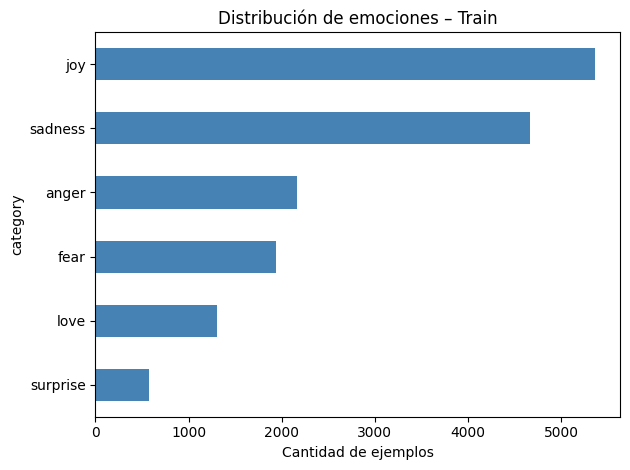

category
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertimos la partición de entrenamiento a pandas para exploración
emotion_dataset.set_format("pandas")
df_emo = emotion_dataset["train"].to_pandas()
df_emo["category"] = df_emo["label"].map(id2label_emo)
emotion_dataset.reset_format()

print(f"Train : {len(emotion_dataset['train']):>6} ejemplos")
print(f"Val   : {len(emotion_dataset['validation']):>6} ejemplos")
print(f"Test  : {len(emotion_dataset['test']):>6} ejemplos")
print()

# Distribución de clases en train
df_emo["category"].value_counts(ascending=True).plot.barh(color="steelblue")
plt.title("Distribución de emociones – Train")
plt.xlabel("Cantidad de ejemplos")
plt.tight_layout()
plt.show()

df_emo["category"].value_counts()

### 2. Cargar el Modelo y el Tokenizer

#### ¿Por qué `Redstoneguru/GPT2-Sentiment-Analysis`?

Este modelo tiene dos propiedades clave para nuestra tarea:

| Propiedad | Detalle |
|-----------|---------|
| **Idioma** | Inglés — coincide con el idioma del dataset `dair-ai/emotion` |
| **Arquitectura** | `GPT2ForSequenceClassification` — ya tiene cabeza de clasificación |
| **Pre-entrenamiento adicional** | Fue fine-tuneado en tweets de sentimiento en inglés; el cuerpo del transformer ya aprendió representaciones semánticas de emociones |

#### ¿Qué pasa con las etiquetas?

El modelo original tiene **3 etiquetas** (negativo / neutro / positivo). Nuestro dataset tiene **6 emociones**. Al cargar con `num_labels=6`:

- **Se reinicializa** solo la capa lineal final (la cabeza de clasificación).
- **Se conservan** todos los pesos del transformer (12 capas de atención, embeddings, etc.).

Esto es **transfer learning en dos etapas**: primero GPT-2 base → luego fine-tuned en sentimiento → finalmente fine-tuned en 6 emociones.

In [21]:
from transformers import GPT2ForSequenceClassification, GPT2Tokenizer

EMO_MODEL_NAME = "Redstoneguru/GPT2-Sentiment-Analysis"
EMO_SUBFOLDER  = "fine_tuned_gpt2"

# El tokenizer ya viene configurado con pad_token = eos_token
tokenizer_emo = GPT2Tokenizer.from_pretrained(EMO_MODEL_NAME, subfolder=EMO_SUBFOLDER)

# Cargamos con num_labels=6: reinicializa la cabeza, conserva el cuerpo
model_emo = GPT2ForSequenceClassification.from_pretrained(
    EMO_MODEL_NAME,
    subfolder=EMO_SUBFOLDER,
    num_labels=len(EMOTION_NAMES),
    id2label=id2label_emo,
    label2id=label2id_emo,
    ignore_mismatched_sizes=True,  # Necesario al cambiar num_labels de 3 → 6
)
model_emo.config.pad_token_id = tokenizer_emo.pad_token_id

print("Arquitectura del modelo:")
print(model_emo)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: Redstoneguru/GPT2-Sentiment-Analysis
Key          | Status   |                                                                                       
-------------+----------+---------------------------------------------------------------------------------------
score.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Arquitectura del modelo:
GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=6, bias=False)
)


### 3. Tokenizar el Dataset

#### Fine-tuning generativo vs. fine-tuning para clasificación

En la sección anterior hicimos fine-tuning **generativo** del modelo GPT-2 sobre chistes. Allí la tarea del modelo era predecir el siguiente token de la secuencia. Por eso necesitábamos que los `labels` fueran simplemente los mismos `input_ids` desplazados una posición:

```
Entrada (input_ids) :  [¿ , C, ó, m, o , s, e , ...]   ← tokens de la frase
Labels (para LM)   :  [C, ó, m, o,  , s, e,  , ...]   ← los mismos tokens, desplazados +1
                        ↑
               El modelo aprende: "después de ¿, viene C"
```

Para **clasificación** la tarea es completamente diferente: el modelo tiene que leer **toda** la frase y decidir cuál de las 6 emociones expresa. Ya no necesitamos que prediga el siguiente token — necesitamos que produzca **una sola etiqueta numérica** (0=sadness, 1=joy, …).

Por eso el tokenizer solo necesita producir:

| Campo | Qué es | Para qué sirve |
|-------|--------|----------------|
| `input_ids` | Lista de enteros — cada uno es el índice del token en el vocabulario de GPT-2 | Le dice al modelo qué palabras contiene la frase |
| `attention_mask` | Lista de 1s y 0s del mismo tamaño que `input_ids` | Le dice al modelo qué posiciones son texto real (1) y cuáles son padding (0), para que no "preste atención" a los tokens de relleno |
| `labels` | Un único entero (0–5) | La emoción correcta para esa frase; la cabeza de clasificación lo usa para calcular el error |

**Visualmente**, para la frase `"I feel sad"` con etiqueta `sadness (0)`:

```
Frase original   →  tokenizer  →   input_ids     = [40, 1254, 6507, ...]  (64 tokens con padding)
                                   attention_mask = [ 1,    1,    1, ..., 1, 0, 0]  (1=real, 0=pad)
                                   labels         = 0   ← sadness
                                                    ↑
                                          Un solo número, no una secuencia
```

---

#### ¿Por qué `max_length=64`?

Las frases del dataset son cortas (~20 palabras en mediana). Un `max_length=64` cubre el 99 % de los ejemplos sin desperdiciar memoria. Usar 1024 (el máximo de GPT-2) haría el entrenamiento ~16× más lento y consumiría mucha más VRAM.

#### `padding="max_length"` vs `padding=True`

- `padding="max_length"` → todos los ejemplos tienen exactamente 64 tokens (padding fijo). Más simple y compatible con datasets cacheados en disco.
- `padding=True` → padding dinámico al máximo de cada batch. Más eficiente con `DataCollatorWithPadding`, pero requiere configuración adicional.

In [22]:
MAX_LEN_EMO = 64

def tokenize_emotion_batch(examples):
    return tokenizer_emo(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN_EMO,
    )

# Aplicamos la tokenización a todo el dataset de forma paralela
tokenized_emo = emotion_dataset.map(tokenize_emotion_batch, batched=True)

# El Trainer espera la columna "labels" (no "label")
tokenized_emo = tokenized_emo.rename_column("label", "labels")

# Configuramos el formato PyTorch; solo las columnas que necesita el modelo
tokenized_emo.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

train_emo = tokenized_emo["train"]
val_emo   = tokenized_emo["validation"]
test_emo  = tokenized_emo["test"]

print(f"Train : {len(train_emo):>6} ejemplos")
print(f"Val   : {len(val_emo):>6} ejemplos")
print(f"Test  : {len(test_emo):>6} ejemplos")
print("\nEjemplo de un batch tokenizado:")
print(train_emo[0])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train :  16000 ejemplos
Val   :   2000 ejemplos
Test  :   2000 ejemplos

Ejemplo de un batch tokenizado:
{'labels': tensor(0), 'input_ids': tensor([   72, 42547,  1254, 42659, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256]), 'attention_mask': tensor([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}


### 4. Fine-Tuning

#### Hiperparámetros clave

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `num_train_epochs` | 3 | Suficiente para convergencia; más épocas pueden causar overfitting en datasets pequeños |
| `learning_rate` | 2e-5 | Tasa baja típica para fine-tuning; evita destruir los pesos pre-entrenados |
| `per_device_train_batch_size` | 16 | Balance entre velocidad y estabilidad del gradiente |
| `warmup_steps` | 200 | Sube el LR gradualmente al inicio para no desestabilizar el modelo |
| `weight_decay` | 0.01 | Regularización L2 para evitar overfitting |
| `eval_strategy` | `"epoch"` | Evalúa al final de cada época para monitorear el aprendizaje |
| `load_best_model_at_end` | `True` | Carga el mejor checkpoint (por F1) al terminar el entrenamiento |
| `fp16` | auto (si hay GPU) | Entrena en precisión media para reducir tiempo y memoria en GPU |

#### Métricas de evaluación

- **Accuracy**: porcentaje de ejemplos clasificados correctamente.
- **F1 macro**: promedio del F1 por clase (importante cuando las clases están desbalanceadas, como en este dataset donde `surprise` tiene solo 719 ejemplos vs 6761 de `joy`).

In [23]:
%%time
import numpy as np
import evaluate
from transformers import TrainingArguments, Trainer

accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics_emo(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")
    return {**acc, **f1}

training_args_emo = TrainingArguments(
    output_dir="./gpt2_emotion_classifier",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=200,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_emo = Trainer(
    model=model_emo,
    args=training_args_emo,
    train_dataset=train_emo,
    eval_dataset=val_emo,
    compute_metrics=compute_metrics_emo,
)

trainer_emo.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.275971,0.219857,0.915000,0.890604
2,0.151181,0.181170,0.934000,0.912517
3,0.136164,0.152414,0.936000,0.913787


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: total: 3min 30s
Wall time: 3min 37s


TrainOutput(global_step=3000, training_loss=0.365864470799764, metrics={'train_runtime': 213.6466, 'train_samples_per_second': 224.67, 'train_steps_per_second': 14.042, 'total_flos': 1567837126656000.0, 'train_loss': 0.365864470799764, 'epoch': 3.0})

### 5. Evaluación en el Conjunto de Test

Evaluamos el modelo **entrenado** sobre el conjunto de test (datos que nunca vio durante el entrenamiento ni la validación). Reportamos:

- **Métricas globales**: Accuracy y F1 macro.
- **Reporte por clase**: precisión, recall y F1 individuales para cada emoción, que nos permiten identificar cuáles son más difíciles de distinguir.

In [24]:
from sklearn.metrics import classification_report

# trainer.predict() ejecuta la inferencia sobre cualquier dataset y calcula
# las métricas definidas en compute_metrics, sin requerir el ciclo de training.
# trainer.evaluate() en cambio activa callbacks que sólo funcionan post-train().
preds_output = trainer_emo.predict(test_emo)

y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

# Las métricas vienen prefijadas con "test_" cuando se usa predict()
print("=== Métricas globales (Test) ===")
print(f"  Accuracy : {preds_output.metrics['test_accuracy']:.4f}")
print(f"  F1 macro : {preds_output.metrics['test_f1']:.4f}")

print("\n=== Reporte de Clasificación por Emoción ===")
print(classification_report(y_true, y_pred, target_names=EMOTION_NAMES))

=== Métricas globales (Test) ===
  Accuracy : 0.9350
  F1 macro : 0.9028

=== Reporte de Clasificación por Emoción ===
              precision    recall  f1-score   support

     sadness       0.97      0.97      0.97       581
         joy       0.97      0.93      0.95       695
        love       0.81      0.89      0.85       159
       anger       0.94      0.93      0.94       275
        fear       0.89      0.91      0.90       224
    surprise       0.76      0.86      0.81        66

    accuracy                           0.94      2000
   macro avg       0.89      0.92      0.90      2000
weighted avg       0.94      0.94      0.94      2000



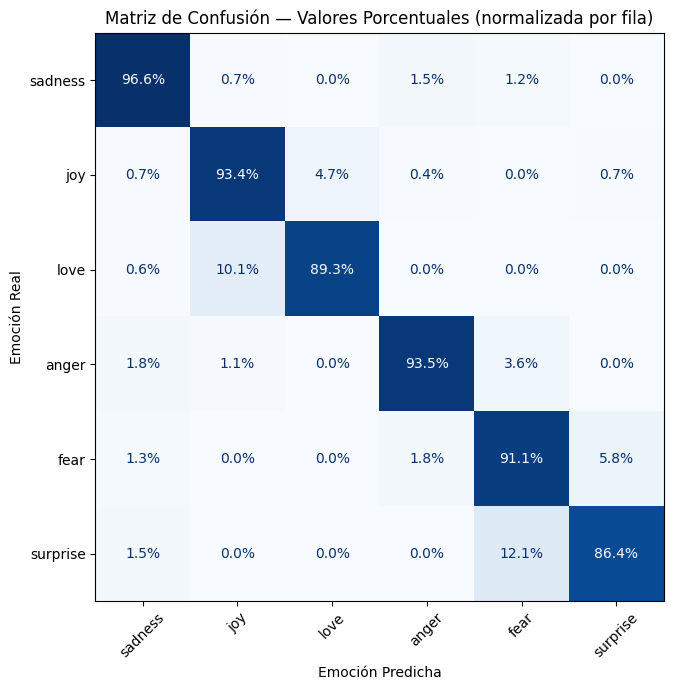

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

# Normalizar por fila: cada celda muestra qué % de la clase real fue predicha como X
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=EMOTION_NAMES)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".1f", colorbar=False)

# Añadir símbolo "%" a cada celda
for text in ax.texts:
    text.set_text(text.get_text() + "%")

ax.set_xlabel("Emoción Predicha")
ax.set_ylabel("Emoción Real")
plt.title("Matriz de Confusión — Valores Porcentuales (normalizada por fila)")
plt.tight_layout()
plt.show()

### 6. Predicción en Frases Nuevas

Creamos una función de inferencia que, dado cualquier texto en inglés, devuelve la emoción predicha y las probabilidades de cada clase.

> **Nota:** Aunque el modelo usa el mismo tokenizer de GPT-2, en esta tarea **no genera texto**. Solo produce una distribución de probabilidad sobre las 6 etiquetas de emoción.

In [13]:
def predict_emotion(text, model, tokenizer, id2label, max_len=64, device="cpu"):
    """
    Predice la emoción de un texto en inglés.
    Retorna (emoción predicha, dict con porcentajes por clase).
    """
    model.eval()
    model.to(device)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
        padding="max_length",
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred_id = logits.argmax(dim=-1).item()
    probs   = torch.softmax(logits, dim=-1)[0]
    prob_dict = {id2label[i]: f"{probs[i]*100:.1f}%" for i in range(len(id2label))}
    return id2label[pred_id], prob_dict


# Tuplas (texto, etiqueta_real) — una frase por cada emoción del dataset
test_phrases = [
    ("im trying to do something often i just look at the whole problem and feel overwhelmed by it then sometimes avoid the issue for as long as i can",              "surprise"),
    ("I feel really sad and lonely after what happened.",    "sadness"),
    ("I love spending time with my family, it makes me feel warm.", "love"),
    ("I am furious about the way they treated me.",          "anger"),
    ("I am terrified of what might happen next.",            "fear"),
    ("I was completely surprised by the unexpected news!",   "surprise"),
    ("I feel so happy and grateful for everything today!",   "joy"),
]

print("=" * 70)
correct = 0
for text, true_label in test_phrases:
    pred_label, probs = predict_emotion(
        text, model_emo, tokenizer_emo, id2label_emo, device=device
    )
    match = "✓" if pred_label == true_label else "✗"
    if pred_label == true_label:
        correct += 1
    print(f"Texto     : {text}")
    print(f"Real      : {true_label.upper()}")
    print(f"Predicha  : {pred_label.upper()}  {match}")
    print(f"Probs     : {probs}")
    print("-" * 70)

print(f"\nAciertos: {correct}/{len(test_phrases)}")

Texto     : im trying to do something often i just look at the whole problem and feel overwhelmed by it then sometimes avoid the issue for as long as i can
Real      : SURPRISE
Predicha  : SURPRISE  ✓
Probs     : {'sadness': '0.1%', 'joy': '0.0%', 'love': '0.1%', 'anger': '0.1%', 'fear': '48.7%', 'surprise': '51.0%'}
----------------------------------------------------------------------
Texto     : I feel really sad and lonely after what happened.
Real      : SADNESS
Predicha  : SADNESS  ✓
Probs     : {'sadness': '100.0%', 'joy': '0.0%', 'love': '0.0%', 'anger': '0.0%', 'fear': '0.0%', 'surprise': '0.0%'}
----------------------------------------------------------------------
Texto     : I love spending time with my family, it makes me feel warm.
Real      : LOVE
Predicha  : LOVE  ✓
Probs     : {'sadness': '0.0%', 'joy': '16.4%', 'love': '83.5%', 'anger': '0.0%', 'fear': '0.0%', 'surprise': '0.0%'}
----------------------------------------------------------------------
Texto     : I am f